In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import io
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# --- SECTION 1: MASTER DATASET ---
csv_content = """artist,album,year,track_count,spotify_mau,hype_score,days_to_release,event_type,feature_track_count,first_week_streams
Ed Sheeran,Divide,2017,16,120,9,21,0,0,375
Ed Sheeran,Equals,2021,14,365,8.5,21,0,0,270
Drake,Scorpion,2018,25,207,9,7,0,3,559
Drake,CLB,2021,21,365,9.5,14,0,12,512
Drake,FATD,2023,23,574,9,14,0,10,411
Travis Scott,ASTROWORLD,2018,17,207,9,14,0,11,350
Travis Scott,Utopia,2023,19,574,8,14,0,13,455
Eminem,TheDeathOfSlimShady,2024,19,640,9.0,45,0,7,382
The Weeknd,AfterHours,2020,14,299,9,21,0,0,450
The Weeknd,HUT,2024,22,640,10,21,0,6,580
Justin Bieber,Justice,2021,16,406,8,14,0,8,252
SZA,SOS,2022,23,489,9,21,0,4,400
Taylor Swift,Midnights,2022,20,489,10,21,0,1,776
Taylor Swift,1989TV,2023,21,574,9,21,0,0,600
Taylor Swift,TTPD,2024,31,640,10,28,0,2,1173
Taylor Swift,LifeOfAShowgirl,2025,12,680,10,45,0,1,920
Sabrina Carpenter,ShortNSweet,2024,12,640,8,21,0,0,450
Sabrina Carpenter,MansBestFriend,2025,13,715,9.5,30,0,0,610
Kendrick Lamar,DAMN,2017,14,120,10,7,0,3,341
Kendrick Lamar,MrMorale,2022,19,422,9.5,25,0,7,338
Kendrick Lamar,GNX,2024,12,640,10,7,1,7,363
Ariana Grande,thankunext,2019,12,207,10,21,0,0,307
Ariana Grande,EternalSunshine,2024,13,620,9,28,0,0,230
Olivia Rodrigo,SOUR,2021,11,365,9,28,0,0,385
Olivia Rodrigo,GUTS,2023,12,574,9,45,0,0,310
Billie Eilish,HMHAS,2024,10,640,9.0,45,0,0,306
Beyonce,CowboyCarter,2024,27,640,9.5,14,0,11,300
Dua Lipa,FutureNostalgia,2020,11,299,8.5,21,0,0,150
Adele,30,2021,12,365,10.0,45,0,0,225
Bad Bunny,UnVeranoSinTi,2022,23,489,10.0,7,0,7,632
Bad Bunny,DebiTirarMasFotos,2025,22,680,10.0,14,0,8,610
Morgan Wallen,OneThingAtATime,2023,36,574,9.0,120,0,3,410
Kanye West,DONDA,2021,27,406,10.0,60,0,18,442
Harry Styles,HarrysHouse,2022,13,489,9.5,52,0,0,385
Harry Styles,KissAllTheTime,2026,12,760,10.0,45,0,0,415"""

df = pd.read_csv(io.StringIO(csv_content))

# --- SECTION 2: TRAINING ---
features = ['year', 'track_count', 'spotify_mau', 'hype_score', 'days_to_release', 'event_type', 'feature_track_count']
X = df[features]
y = df['first_week_streams']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# --- SECTION 3: PREDICTION LOGIC ---
def predict_with_range(model, params, features, confidence=0.8):
    input_data = pd.DataFrame([params], columns=features).values
    tree_preds = np.array([tree.predict(input_data)[0] for tree in model.estimators_])
    mean_pred = np.mean(tree_preds)
    std_dev = np.std(tree_preds)
    lower_bound = max(0, mean_pred - (confidence * std_dev))
    upper_bound = mean_pred + (confidence * std_dev)
    return mean_pred, lower_bound, upper_bound

# --- SECTION 4: 2026 SUMMER BLOCKBUSTER PROJECTIONS ---
market_mau = 760
proj_year = 2026

d_t, o_t, a_t = 20, 13, 14
d_params = [proj_year, d_t, market_mau, 10.0, 24, 0, 2]
o_params = [proj_year, o_t, market_mau, 9.5, 52, 0, 0]
a_params = [proj_year, a_t, market_mau, 9.0, 28, 0, 1]

d_m, d_l, d_h = predict_with_range(model, d_params, features)
o_m, o_l, o_h = predict_with_range(model, o_params, features)
a_m, a_l, a_h = predict_with_range(model, a_params, features)

print(f"\n🎧 2026 SUMMER BLOCKBUSTER PREDICTIONS (Updated: April 21)")
print("="*80)
print(f"1. DRAKE  | {d_m:,.0f}M (SPT: {d_m/d_t:.1f}M) | Likely Range: [{d_l:,.0f}M - {d_h:,.0f}M]")
print(f"2. OLIVIA | {o_m:,.0f}M (SPT: {o_m/o_t:.1f}M) | Likely Range: [{o_l:,.0f}M - {o_h:,.0f}M]")
print(f"3. ARIANA | {a_m:,.0f}M (SPT: {a_m/a_t:.1f}M) | Likely Range: [{a_l:,.0f}M - {a_h:,.0f}M]")
print("-" * 80)
print(f"Stats: Spotify {market_mau}M MAU | {len(df)} historical entries")
print("="*80)


🎧 2026 SUMMER BLOCKBUSTER PREDICTIONS (Updated: April 21)
1. DRAKE  | 690M (SPT: 34.5M) | Likely Range: [514M - 866M]
2. OLIVIA | 530M (SPT: 40.7M) | Likely Range: [389M - 670M]
3. ARIANA | 570M (SPT: 40.8M) | Likely Range: [416M - 725M]
--------------------------------------------------------------------------------
Stats: Spotify 760M MAU | 35 historical entries


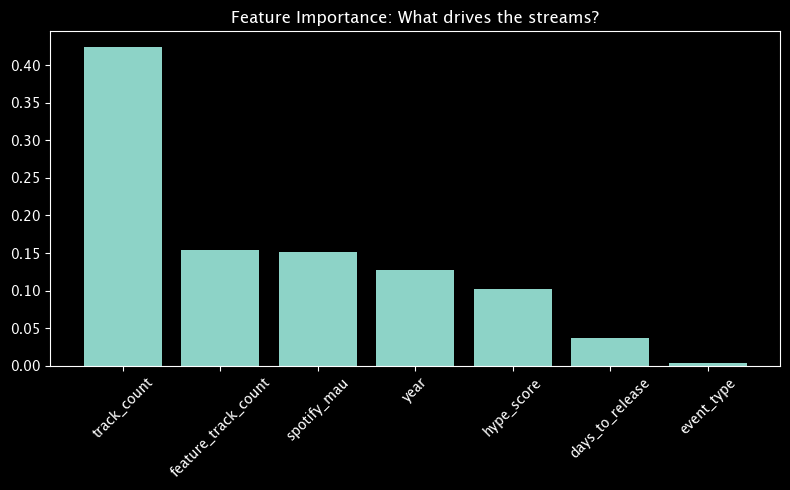

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Get importance values from the trained model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the results
plt.figure(figsize=(8, 5))
plt.title("Feature Importance: What drives the streams?")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()